In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
!pip install openexr torch torchvision numpy

In [17]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import OpenEXR, Imath
from tqdm import tqdm

EPSILON = 0.00316
device = "cuda" if torch.cuda.is_available() else "cpu"

In [18]:
def read_exr_channels(path, channels):
    exr = OpenEXR.InputFile(path)
    dw = exr.header()['dataWindow']
    W = dw.max.x - dw.min.x + 1
    H = dw.max.y - dw.min.y + 1
    FLOAT = Imath.PixelType(Imath.PixelType.FLOAT)

    result = {}
    for ch in channels:
        raw = np.frombuffer(exr.channel(ch, FLOAT), dtype=np.float32)
        result[ch] = raw.reshape(H, W)
    return result


def load_noisy_buffers(path):
    needed = [
        'diffuse.R','diffuse.G','diffuse.B',
        'diffuseA.R','diffuseA.G','diffuseA.B',
        'specular.R','specular.G','specular.B',
        'specularA.R','specularA.G','specularA.B',
        'albedo.R','albedo.G','albedo.B',
        'normal.R','normal.G','normal.B',
        'normalA.R','normalA.G','normalA.B',
        'depth.Z','depthA.Z'
    ]

    ch = read_exr_channels(path, needed)

    def rgb(prefix):
        return np.stack([ch[f'{prefix}.R'], ch[f'{prefix}.G'], ch[f'{prefix}.B']], axis=-1)

    diffuse1 = rgb('diffuse')
    diffuse2 = rgb('diffuseA')
    spec1 = rgb('specular')
    spec2 = rgb('specularA')

    return {
        'diffuse': diffuse1,
        'specular': spec1,
        'albedo': rgb('albedo'),
        'normal': rgb('normal'),
        'depth': ch['depth.Z'][..., None],

        'sigma2_diffuse': 0.5*(diffuse1 - diffuse2)**2,
        'sigma2_specular': 0.5*(spec1 - spec2)**2,
        'sigma2_normal': 0.5*(rgb('normal') - rgb('normalA'))**2
    }


def load_reference_buffers(path):
    needed = [
        'diffuse.R','diffuse.G','diffuse.B',
        'specular.R','specular.G','specular.B',
        'albedo.R','albedo.G','albedo.B'
    ]

    ch = read_exr_channels(path, needed)

    def rgb(prefix):
        return np.stack([ch[f'{prefix}.R'], ch[f'{prefix}.G'], ch[f'{prefix}.B']], axis=-1)

    return {
        'diffuse': rgb('diffuse'),
        'specular': rgb('specular'),
        'albedo': rgb('albedo')
    }

In [19]:
def to_lum(x):
    return 0.2126*x[...,0:1] + 0.7152*x[...,1:2] + 0.0722*x[...,2:3]

def grad(x):
    return np.gradient(x, axis=1), np.gradient(x, axis=0)


def preprocess_diffuse(b):
    depth = to_lum(b['depth'])
    irradiance = b['diffuse'] / (b['albedo'] + EPSILON)

    sigma2 = to_lum(b['sigma2_diffuse'])
    sigma2_norm = to_lum(b['sigma2_normal'])

    gx, gy = grad(irradiance)
    nx, ny = grad(b['normal'])
    dx, dy = grad(depth)

    feat = np.concatenate([
        irradiance, gx, gy,
        b['normal'], nx, ny,
        depth, dx, dy,
        sigma2, sigma2_norm,
        b['albedo']   # 🔥 make sure this exists
    ], axis=-1)

    # 🔍 FINAL CHECK
    # print("FINAL DIFFUSE FEATURE SHAPE:", feat.shape)

    return feat, irradiance


def preprocess_specular(b):
    depth = to_lum(b['depth'])
    spec = np.log1p(b['specular'])

    sigma2 = to_lum(b['sigma2_specular'])
    sigma2_norm = to_lum(b['sigma2_normal'])

    gx, gy = grad(spec)
    nx, ny = grad(b['normal'])
    dx, dy = grad(depth)

    feat = np.concatenate([
        spec, gx, gy,
        b['normal'], nx, ny,
        depth, dx, dy,
        sigma2, sigma2_norm,
        b['albedo']
    ], axis=-1)

    # 🔍 FINAL CHECK
    # print("FINAL SPEC FEATURE SHAPE:", feat.shape)

    return feat, spec

In [20]:
class KPCN(nn.Module):
    def __init__(self, in_channels=23, kernel_size=21):
        super().__init__()
        self.kernel_size = kernel_size

        layers = [nn.Conv2d(in_channels, 100, 5, padding=2), nn.ReLU()]
        for _ in range(7):
            layers += [nn.Conv2d(100, 100, 5, padding=2), nn.ReLU()]
        layers += [nn.Conv2d(100, kernel_size*kernel_size, 1)]

        self.net = nn.Sequential(*layers)

    def forward(self, feat, noisy):
        B, C, H, W = noisy.shape
        k = self.kernel_size

        w = self.net(feat)
        w = F.softmax(w, dim=1)

        patches = F.unfold(noisy, k, padding=k//2)
        patches = patches.view(B, 3, k*k, H*W)

        w = w.view(B, k*k, H*W).unsqueeze(1)

        out = (patches * w).sum(dim=2)
        return out.view(B, 3, H, W)

In [21]:
class KPCNDataset(Dataset):
    def __init__(self, pairs, patch_size=65, full_image=False):
        self.pairs = pairs
        self.patch_size = patch_size
        self.full_image = full_image

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        noisy_path, ref_path = self.pairs[idx]

        nb = load_noisy_buffers(noisy_path)
        rb = load_reference_buffers(ref_path)

        diff_feat, diff_irr = preprocess_diffuse(nb)
        spec_feat, spec_log = preprocess_specular(nb)

        diff_gt = rb['diffuse'] / (rb['albedo'] + EPSILON)
        spec_gt = np.log1p(rb['specular'])

        albedo = nb['albedo']

        H, W = diff_feat.shape[:2]
        if not self.full_image:
          ps = self.patch_size

          top = np.random.randint(0, H-ps)
          left = np.random.randint(0, W-ps)

          def crop(x):
            return x[top:top+ps, left:left+ps]

        else:
          crop = lambda x: x

        return {
            "diff_feat": torch.from_numpy(crop(diff_feat)).permute(2,0,1).float(),
            "diff_irr": torch.from_numpy(crop(diff_irr)).permute(2,0,1).float(),
            "diff_gt": torch.from_numpy(crop(diff_gt)).permute(2,0,1).float(),

            "spec_feat": torch.from_numpy(crop(spec_feat)).permute(2,0,1).float(),
            "spec_log": torch.from_numpy(crop(spec_log)).permute(2,0,1).float(),
            "spec_gt": torch.from_numpy(crop(spec_gt)).permute(2,0,1).float(),

            "albedo": torch.from_numpy(crop(albedo)).permute(2,0,1).float()
        }

In [22]:
def find_pairs(scene_dirs):
    pairs = []
    for d in scene_dirs:
        for f in os.listdir(d):
            if "00128spp" in f:
                base = f.replace("-00128spp.exr", "")
                ref = os.path.join(d, base + "-08192spp.exr")
                noisy = os.path.join(d, f)
                if os.path.exists(ref):
                    pairs.append((noisy, ref))
    return pairs

In [23]:
import os

checkpoint_dir = "/content/drive/MyDrive/469_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

train_pairs = find_pairs(["/content/drive/MyDrive/469_data/room2","/content/drive/MyDrive/469_data/room3"])
test_pairs = find_pairs(["/content/drive/MyDrive/469_data/car2"])

train_dataset = KPCNDataset(train_pairs)
test_dataset = KPCNDataset(test_pairs, full_image=True)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

diff_net = KPCN().to(device)
spec_net = KPCN().to(device)

optimizer = torch.optim.Adam(
    list(diff_net.parameters()) + list(spec_net.parameters()),
    lr=1e-4
)

loss_fn = nn.L1Loss()

In [24]:
import os


def compute_psnr(pred, target):
    mse = F.mse_loss(pred, target)
    return -10 * torch.log10(mse + 1e-8)

checkpoint_dir = "/content/drive/MyDrive/469_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

train_pairs = find_pairs(["/content/drive/MyDrive/469_data/room2","/content/drive/MyDrive/469_data/room3"])
test_pairs = find_pairs(["/content/drive/MyDrive/469_data/car2"])

train_dataset = KPCNDataset(train_pairs)
test_dataset = KPCNDataset(test_pairs, full_image=True)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

diff_net = KPCN().to(device)
spec_net = KPCN().to(device)

optimizer = torch.optim.Adam(
    list(diff_net.parameters()) + list(spec_net.parameters()),
    lr=1e-4
)

loss_fn = nn.L1Loss()

epochs = 10

train_losses = []
train_psnrs = []

for e in range(epochs):

    diff_net.train()
    spec_net.train()

    total_loss = 0
    total_psnr = 0

    for batch in tqdm(train_loader):

        diff_feat = batch["diff_feat"].to(device)
        diff_irr = batch["diff_irr"].to(device)
        diff_gt = batch["diff_gt"].to(device)

        spec_feat = batch["spec_feat"].to(device)
        spec_log = batch["spec_log"].to(device)
        spec_gt = batch["spec_gt"].to(device)

        albedo = batch["albedo"].to(device)

        optimizer.zero_grad()

        out_diff = diff_net(diff_feat, diff_irr)
        out_spec = spec_net(spec_feat, spec_log)

        pred = (out_diff * (albedo + EPSILON)) + torch.expm1(out_spec)
        gt = (diff_gt * (albedo + EPSILON)) + torch.expm1(spec_gt)

        loss = loss_fn(pred, gt)
        psnr = compute_psnr(pred, gt)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_psnr += psnr.item()

    avg_loss = total_loss / len(train_loader)
    avg_psnr = total_psnr / len(train_loader)

    train_losses.append(avg_loss)
    train_psnrs.append(avg_psnr)
    print(f"Epoch {e+1}: {avg_loss:.4f}")

    if (e + 1) % 3 == 0:
        checkpoint_path = f"{checkpoint_dir}/kpcn_epoch_{e+1}.pt"

        torch.save({
            'epoch': e + 1,
            'diff_net': diff_net.state_dict(),
            'spec_net': spec_net.state_dict(),
            'optimizer': optimizer.state_dict(),
            'loss': avg_loss
        }, checkpoint_path)

        print(f"Checkpoint saved at epoch {e+1}")

100%|██████████| 97/97 [1:02:53<00:00, 38.90s/it]


Epoch 1: 0.3470


100%|██████████| 97/97 [53:12<00:00, 32.91s/it]


Epoch 2: 0.2535


100%|██████████| 97/97 [52:59<00:00, 32.78s/it]


...

Epoch 8: 0.3000


100%|██████████| 97/97 [53:11<00:00, 32.90s/it]


Epoch 9: 0.4260
Checkpoint saved at epoch 9


100%|██████████| 97/97 [53:44<00:00, 33.25s/it]

Epoch 10: 0.2402


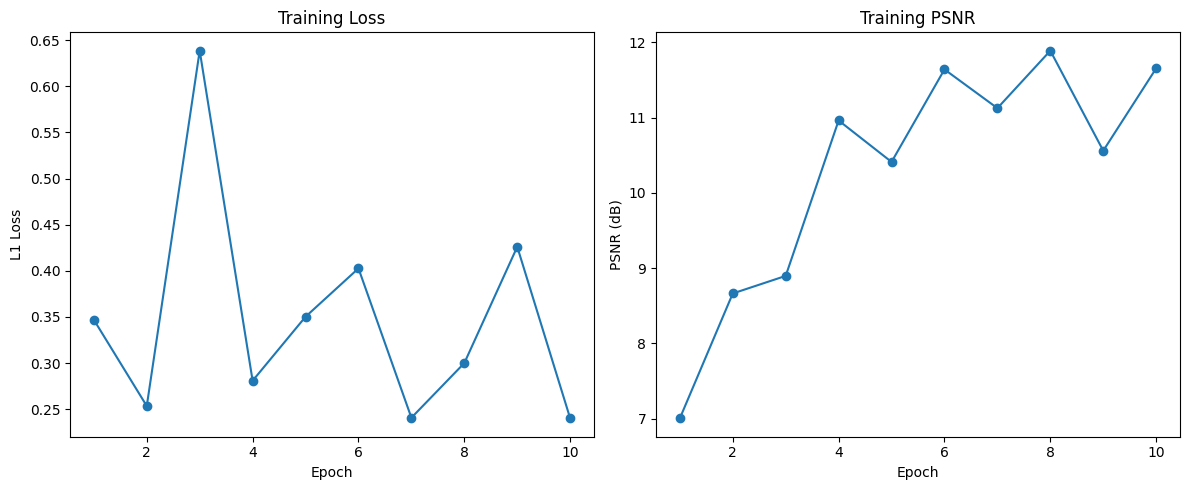

In [25]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs+1)

plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(epochs_range, train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("L1 Loss")

# PSNR plot
plt.subplot(1,2,2)
plt.plot(epochs_range, train_psnrs, marker='o')
plt.title("Training PSNR")
plt.xlabel("Epoch")
plt.ylabel("PSNR (dB)")

plt.tight_layout()
plt.show()

In [26]:
import torch
import torch.nn.functional as F
import numpy as np
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt

def compute_psnr(pred, target):
    mse = F.mse_loss(pred, target)
    return -10 * torch.log10(mse + 1e-8)

def compute_ssim(pred, target):
    pred_np = pred.squeeze(0).permute(1,2,0).cpu().numpy()
    target_np = target.squeeze(0).permute(1,2,0).cpu().numpy()
    return ssim(pred_np, target_np, channel_axis=2, data_range=1.0)

# =========================
# 🔹 EVALUATION FUNCTION
# =========================

device = "cuda" if torch.cuda.is_available() else "cpu"

checkpoint_path = "/content/drive/MyDrive/469_checkpoints/kpcn_epoch_3.pt"

# recreate models
diff_net = KPCN().to(device)
spec_net = KPCN().to(device)

# load checkpoint
checkpoint = torch.load(checkpoint_path, map_location=device)

diff_net.load_state_dict(checkpoint['diff_net'])
spec_net.load_state_dict(checkpoint['spec_net'])

diff_net.eval()
spec_net.eval()

print(f"Loaded checkpoint from epoch {checkpoint['epoch']}")

def evaluate_model(diff_net, spec_net, test_loader, device):
    diff_net.eval()
    spec_net.eval()

    total_loss = 0
    total_psnr = 0
    total_ssim = 0
    count = 0

    loss_fn = torch.nn.L1Loss()

    with torch.no_grad():
        for batch in test_loader:
            diff_feat = batch["diff_feat"].to(device)
            diff_irr  = batch["diff_irr"].to(device)
            diff_gt   = batch["diff_gt"].to(device)

            spec_feat = batch["spec_feat"].to(device)
            spec_log  = batch["spec_log"].to(device)
            spec_gt   = batch["spec_gt"].to(device)

            albedo = batch["albedo"].to(device)

            # 🔥 Forward pass
            out_diff = diff_net(diff_feat, diff_irr)
            out_spec = spec_net(spec_feat, spec_log)

            pred = (out_diff * (albedo + EPSILON)) + torch.expm1(out_spec)
            gt   = (diff_gt * (albedo + EPSILON)) + torch.expm1(spec_gt)

            loss = loss_fn(pred, gt)

            psnr_val = compute_psnr(pred, gt)
            ssim_val = compute_ssim(pred, gt)

            total_loss += loss.item()
            total_psnr += psnr_val.item()
            total_ssim += ssim_val
            count += 1

    print("\n===== EVALUATION RESULTS =====")
    print(f"Avg Loss : {total_loss / count:.4f}")
    print(f"Avg PSNR : {total_psnr / count:.2f} dB")
    print(f"Avg SSIM : {total_ssim / count:.4f}")

    return total_loss / count, total_psnr / count, total_ssim / count

evaluate_model(diff_net, spec_net, test_loader, device)

Loaded checkpoint from epoch 3

===== EVALUATION RESULTS =====
Avg Loss : 0.0242
Avg PSNR : 21.50 dB
Avg SSIM : 0.8589


(0.024244979712077314, 21.498088885347048, np.float32(0.858869))

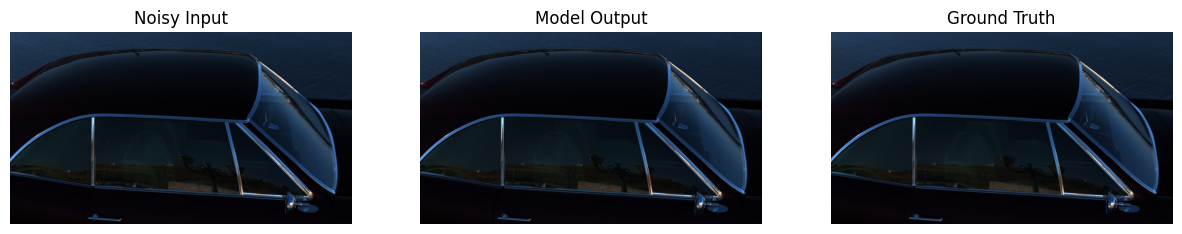

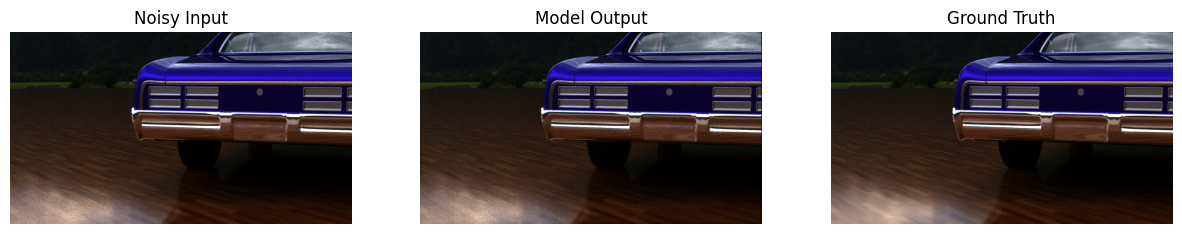

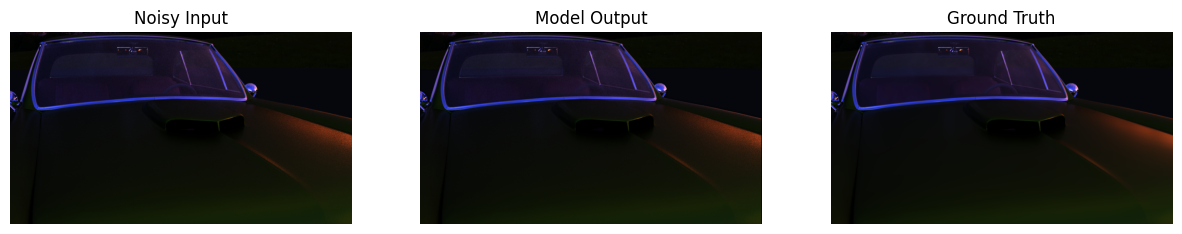

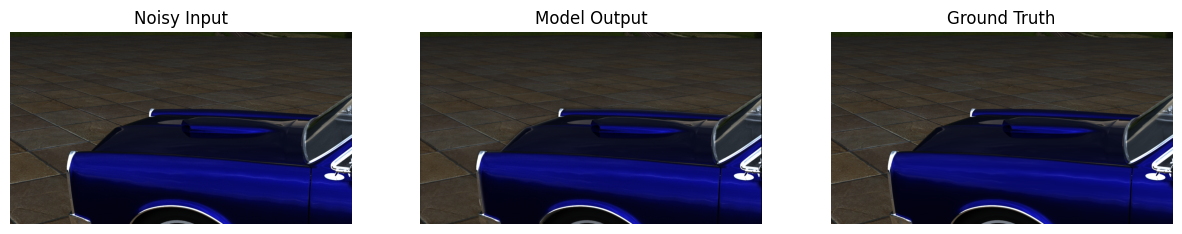

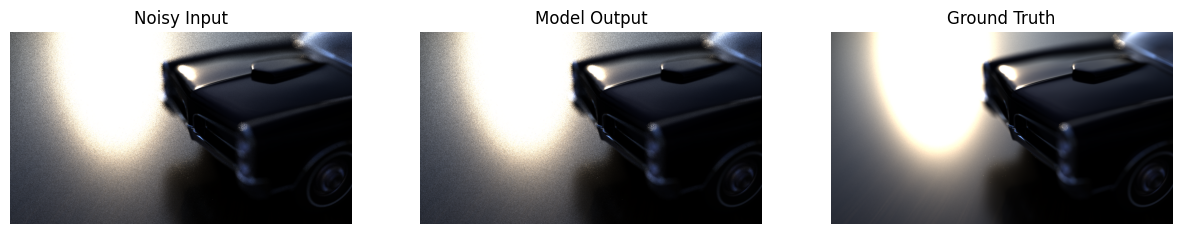

In [28]:
def visualize_results(diff_net, spec_net, test_dataset, device, num_samples=5):
    diff_net.eval()
    spec_net.eval()

    indices = np.random.choice(len(test_dataset), num_samples, replace=False)

    with torch.no_grad():
        for i in indices:
            sample = test_dataset[i]

            diff_feat = sample["diff_feat"].unsqueeze(0).to(device)
            diff_irr  = sample["diff_irr"].unsqueeze(0).to(device)
            spec_feat = sample["spec_feat"].unsqueeze(0).to(device)
            spec_log  = sample["spec_log"].unsqueeze(0).to(device)
            albedo    = sample["albedo"].unsqueeze(0).to(device)

            diff_gt = sample["diff_gt"].unsqueeze(0).to(device)
            spec_gt = sample["spec_gt"].unsqueeze(0).to(device)

            out_diff = diff_net(diff_feat, diff_irr)
            out_spec = spec_net(spec_feat, spec_log)

            pred = (out_diff * (albedo + EPSILON)) + torch.expm1(out_spec)
            gt   = (diff_gt * (albedo + EPSILON)) + torch.expm1(spec_gt)

            noisy = (diff_irr * (albedo + EPSILON)) + torch.expm1(spec_log)

            # Convert to numpy
            noisy_np = noisy.squeeze(0).permute(1,2,0).cpu().numpy()
            pred_np  = pred.squeeze(0).permute(1,2,0).cpu().numpy()
            gt_np    = gt.squeeze(0).permute(1,2,0).cpu().numpy()

            noisy_np = np.clip(noisy_np, 0, 1)
            pred_np  = np.clip(pred_np, 0, 1)
            gt_np    = np.clip(gt_np, 0, 1)

            plt.figure(figsize=(15,5))

            plt.subplot(1,3,1)
            plt.title("Noisy Input")
            plt.imshow(noisy_np)
            plt.axis("off")

            plt.subplot(1,3,2)
            plt.title("Model Output")
            plt.imshow(pred_np)
            plt.axis("off")

            plt.subplot(1,3,3)
            plt.title("Ground Truth")
            plt.imshow(gt_np)
            plt.axis("off")

            plt.show()

visualize_results(diff_net, spec_net, test_dataset, device)

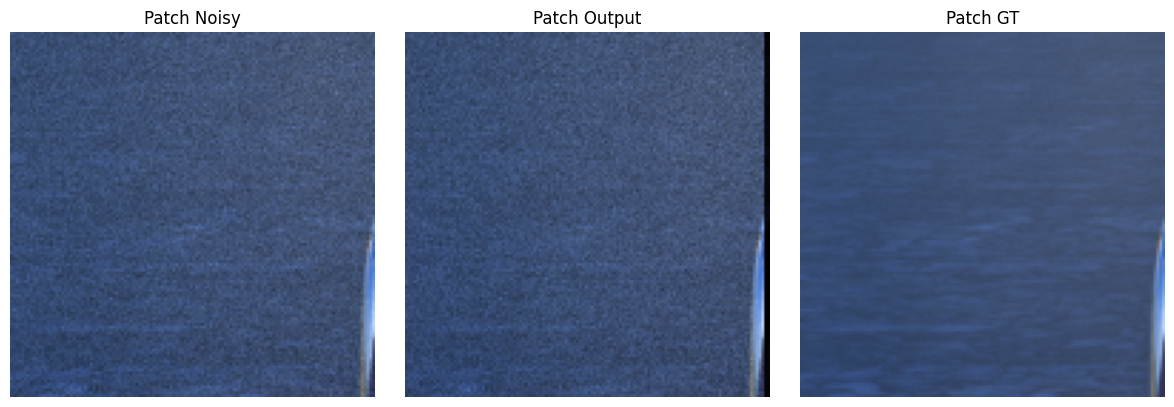

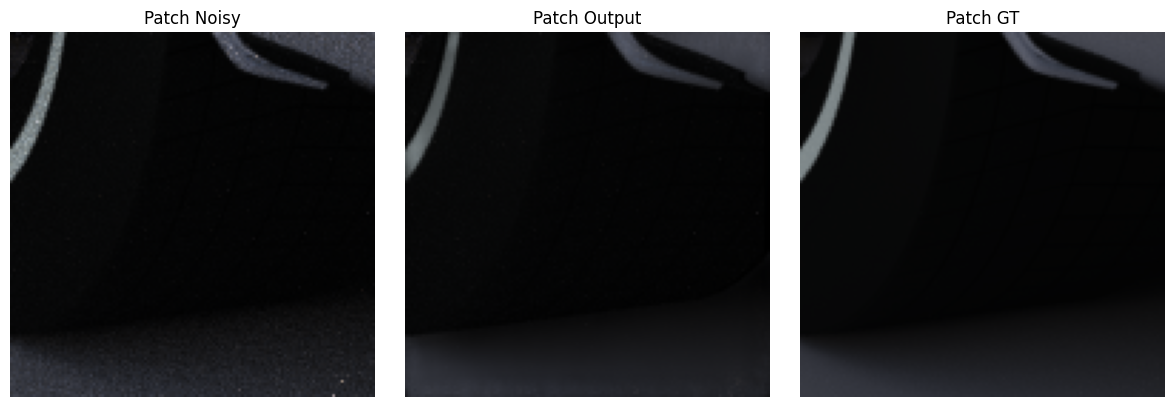

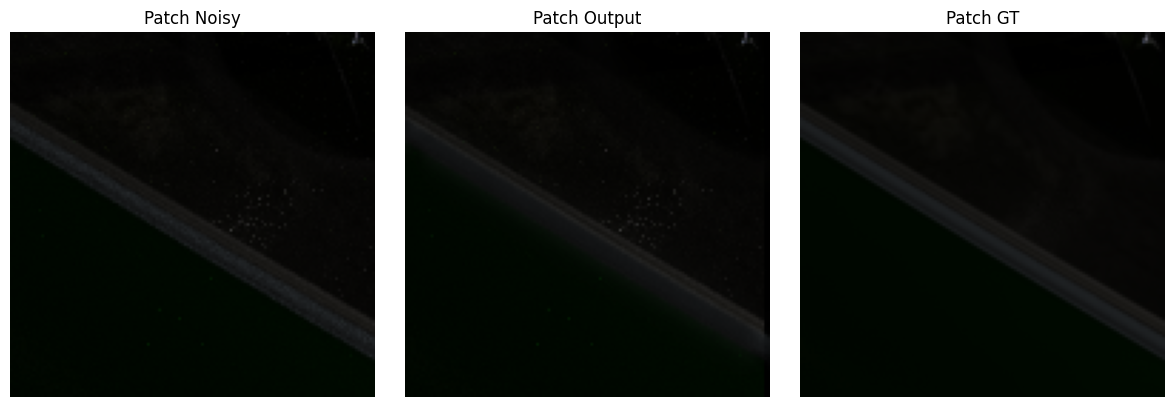

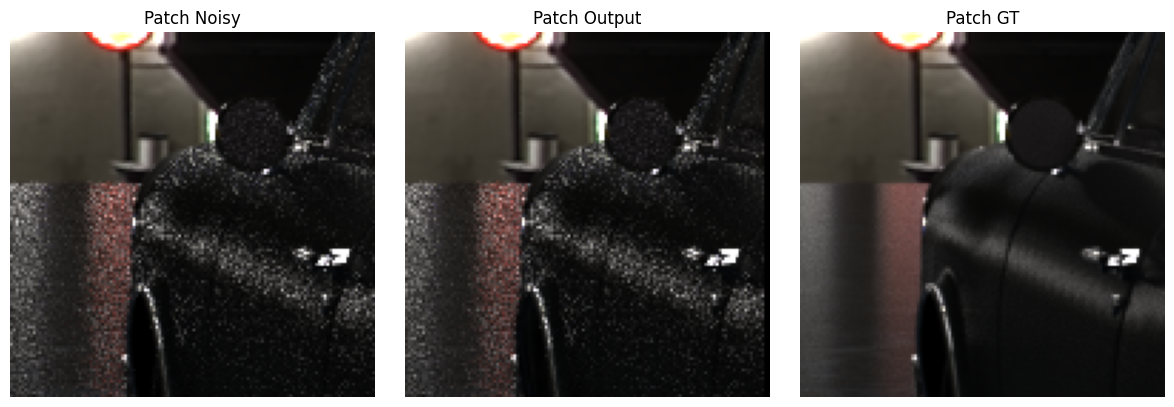

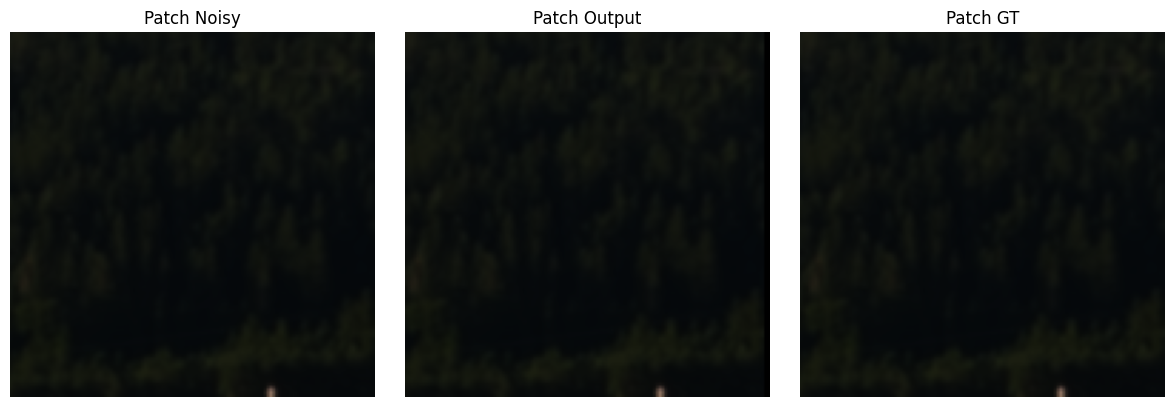

In [31]:
def visualize_patches(diff_net, spec_net, test_dataset, device, num_samples=5, patch_size=128):
    diff_net.eval()
    spec_net.eval()

    indices = np.random.choice(len(test_dataset), num_samples, replace=False)

    with torch.no_grad():
        for i in indices:
            sample = test_dataset[i]

            # Get full image tensors (C,H,W)
            diff_feat = sample["diff_feat"]
            diff_irr  = sample["diff_irr"]
            spec_feat = sample["spec_feat"]
            spec_log  = sample["spec_log"]
            albedo    = sample["albedo"]

            diff_gt = sample["diff_gt"]
            spec_gt = sample["spec_gt"]

            _, H, W = diff_feat.shape

            # 🔥 Random crop
            top  = np.random.randint(0, H - patch_size)
            left = np.random.randint(0, W - patch_size)

            def crop(x):
                return x[:, top:top+patch_size, left:left+patch_size]

            diff_feat = crop(diff_feat).unsqueeze(0).to(device)
            diff_irr  = crop(diff_irr).unsqueeze(0).to(device)
            spec_feat = crop(spec_feat).unsqueeze(0).to(device)
            spec_log  = crop(spec_log).unsqueeze(0).to(device)
            albedo    = crop(albedo).unsqueeze(0).to(device)

            diff_gt = crop(diff_gt).unsqueeze(0).to(device)
            spec_gt = crop(spec_gt).unsqueeze(0).to(device)

            # Forward
            out_diff = diff_net(diff_feat, diff_irr)
            out_spec = spec_net(spec_feat, spec_log)

            pred = (out_diff * (albedo + EPSILON)) + torch.expm1(out_spec)
            gt   = (diff_gt * (albedo + EPSILON)) + torch.expm1(spec_gt)
            noisy = (diff_irr * (albedo + EPSILON)) + torch.expm1(spec_log)

            # Clamp
            noisy = torch.clamp(noisy, 0, 1)
            pred  = torch.clamp(pred, 0, 1)
            gt    = torch.clamp(gt, 0, 1)

            # Convert
            noisy_np = noisy.squeeze(0).permute(1,2,0).cpu().numpy()
            pred_np  = pred.squeeze(0).permute(1,2,0).cpu().numpy()
            gt_np    = gt.squeeze(0).permute(1,2,0).cpu().numpy()

            # Plot
            plt.figure(figsize=(12,4))

            plt.subplot(1,3,1)
            plt.title("Patch Noisy")
            plt.imshow(noisy_np)
            plt.axis("off")

            plt.subplot(1,3,2)
            plt.title("Patch Output")
            plt.imshow(pred_np)
            plt.axis("off")

            plt.subplot(1,3,3)
            plt.title("Patch GT")
            plt.imshow(gt_np)
            plt.axis("off")

            plt.tight_layout()
            plt.show()

visualize_patches(diff_net, spec_net, test_dataset, device)